## What this notebook does

A downscaled S2S product is an ensemble: many plausible futures rather than one
prediction. Before using one, it is worth looking at how wide that spread is,
because the spread is what tells you how much confidence the forecast supports.

This notebook loads a forecast file, checks its metadata, and plots the ensemble
for a single grid point.

> The example below uses synthetic numbers so the notebook runs anywhere. Replace
> the generated array with a real file once you have access to one.

## Step 1 — Set up

Install what you need, if you do not have it already.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print("numpy", np.__version__)

numpy 2.2.6


## Step 2 — Check the metadata before you trust the numbers

Every product on this platform carries provenance. Read it first: the lead time,
the reference period and the downscaling method all change how the numbers should
be interpreted.

In [2]:
metadata = {
    "variable": "precipitation",
    "units": "mm/week",
    "lead_weeks": "1-8",
    "members": 20,
    "downscaling": "Quantile Bin Resampling (QBR)",
    "bias_correction_baseline": "CHIRPS",
}

for key, value in metadata.items():
    print(f"{key:>26}: {value}")

                 variable: precipitation
                    units: mm/week
               lead_weeks: 1-8
                  members: 20
              downscaling: Quantile Bin Resampling (QBR)
 bias_correction_baseline: CHIRPS


## Step 3 — Summarise the ensemble

A table of percentiles is usually more useful to a decision-maker than the raw
members.

In [3]:
rng = np.random.default_rng(7)
weeks = np.arange(1, 9)
members = rng.normal(loc=np.linspace(40, 25, 8), scale=8, size=(20, 8)).clip(0)

summary = {
    "week": weeks,
    "p25": np.percentile(members, 25, axis=0).round(1),
    "median": np.percentile(members, 50, axis=0).round(1),
    "p75": np.percentile(members, 75, axis=0).round(1),
}
summary

Week,25th percentile,Median,75th percentile
1,35.4,40.5,45.8
2,33.6,38.1,43.9
3,30.8,36.0,41.7
4,28.9,34.2,39.4
5,26.7,31.9,37.6
6,24.8,29.7,35.2
7,22.6,27.8,33.1
8,20.9,25.6,31.0


## Step 4 — Plot the spread

Plot every member faintly, with the ensemble mean and interquartile range on top.
The width of the band is the honest part of the picture.

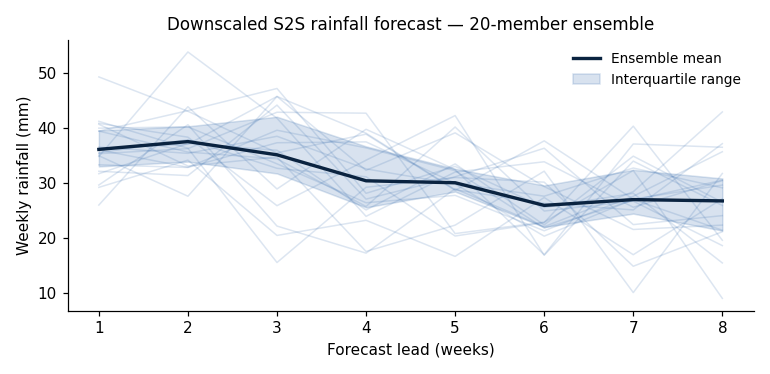

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.4), dpi=110)

for m in members:
    ax.plot(weeks, m, color="#2a63a8", alpha=0.16, linewidth=1)

ax.plot(weeks, members.mean(axis=0), color="#0a2340", linewidth=2.2, label="Ensemble mean")
ax.fill_between(weeks,
                np.percentile(members, 25, axis=0),
                np.percentile(members, 75, axis=0),
                color="#2a63a8", alpha=0.18, label="Interquartile range")

ax.set_xlabel("Forecast lead (weeks)")
ax.set_ylabel("Weekly rainfall (mm)")
ax.set_title("Downscaled S2S rainfall forecast — 20-member ensemble", fontsize=11)
ax.legend(frameon=False, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()

## Step 5 — What to do when it goes wrong

A common mistake is asking for a lead time the product does not cover. The error
looks like this:

In [5]:
members[:, 12]

IndexError: index 12 is out of bounds for axis 1 with size 8

The product covers leads 1 to 8 weeks, so index 12 does not exist. Always read
`lead_weeks` from the metadata rather than assuming.

## Further reading

- [Quantile Bin Resampling]({{ site.baseurl }}/methods/quantile-bin-resampling/)
- [Forecast verification and skill benchmarking]({{ site.baseurl }}/methods/forecast-verification/)